#  Task 2: Real-Time Anomaly Detection System

## Project Overview

This project focuses on building a real-time anomaly detection system for monitoring CPU utilization metrics generated from operational systems. Modern applications continuously produce time-series data such as CPU usage, memory consumption, and system load. Detecting unusual patterns in this data is critical for preventing system failures and ensuring smooth performance.

In this system, we analyze CPU utilization data and apply statistical and machine learning techniques to identify abnormal behavior without requiring labeled data. The system is designed to simulate real-world monitoring pipelines used in production environments.

##  Objectives

- Analyze time-series CPU utilization data
- Detect anomalies using statistical methods (Z-score)
- Apply machine learning techniques for unsupervised anomaly detection
- Visualize system behavior over time
- Build a foundation for real-time monitoring and alerting systems

##  Techniques Used

- Exploratory Data Analysis (EDA)
- Time-series visualization
- Data preprocessing and standardization
- Statistical anomaly detection (Z-score method)
- Machine Learning models (Isolation Forest, PyOD)

##  Dataset Description

The dataset contains CPU utilization metrics with the following columns:

- **timestamp**: Time of measurement  
- **value**: CPU utilization percentage  

The dataset represents real-world system behavior and does not include labeled anomalies, making it suitable for unsupervised anomaly detection techniques.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv(r"../dataset/raw/cpu_utilization_asg_misconfiguration.csv")

In [10]:
data.head()

,timestamp,value
0,5/14/2014 1:14,85.835
1,5/14/2014 1:19,88.167
2,5/14/2014 1:24,44.595
3,5/14/2014 1:29,56.282
4,5/14/2014 1:34,36.534


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18050 entries, 0 to 18049
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  18050 non-null  object 
 1   value      18050 non-null  float64
dtypes: float64(1), object(1)
memory usage: 282.2+ KB


In [12]:
data.describe()

,value
count,18050.000000
mean,38.282756
std,15.639294
min,11.529000
25%,30.789000
50%,32.001000
75%,35.660500
max,100.000000


In [13]:
data.isnull().sum()

timestamp    0
value        0
dtype: int64

In [14]:
data.nunique()

timestamp    18050
value         7150
dtype: int64

In [15]:
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")
data = data.dropna(subset=["timestamp"])
data = data.set_index("timestamp")

In [16]:
data.head()

,value
timestamp,
2014-05-14 01:14:00,85.835
2014-05-14 01:19:00,88.167
2014-05-14 01:24:00,44.595
2014-05-14 01:29:00,56.282
2014-05-14 01:34:00,36.534


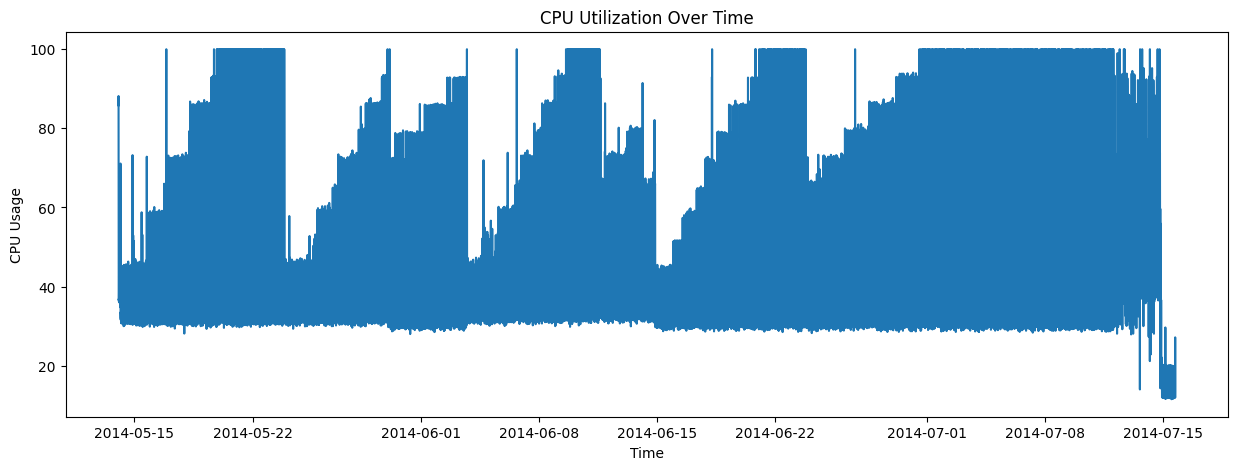

In [17]:

plt.figure(figsize=(15,5))
plt.plot(data.index, data["value"])
plt.title("CPU Utilization Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.show()

# Statistical Anomaly Detection Using Z-Score

##  Overview

In this section, statistical anomaly detection is performed using the Z-score method. The objective is to identify unusual CPU utilization patterns by measuring how far each data point deviates from the overall mean behavior.

The preprocessing pipeline is first applied to clean and prepare the dataset, including timestamp handling and missing value treatment. After preprocessing, the Z-score technique is used to detect abnormal CPU usage values.

##  Workflow

1. Import preprocessing and anomaly detection modules  
2. Apply preprocessing pipeline  
3. Compute Z-scores for CPU utilization values  
4. Detect anomalies using threshold-based statistical analysis  
5. Visualize detected anomalies on time-series data

In [18]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

print(project_root)

C:\Projects\TEYZIX-CORE-INTERNSHIP\task_2_Anomaly_Detection_System


In [21]:
from app.ml.preprocessing import preprocess
from app.ml.statistical import detect_anomalies_zscore

In [24]:
data = pd.read_csv(r"../dataset/raw/cpu_utilization_asg_misconfiguration.csv")

In [25]:
data = preprocess(data)

In [26]:
result = detect_anomalies_zscore(data)

In [27]:
result[result["anomaly"] == True].head()

,value,z_score,anomaly
timestamp,,,
2014-05-14 01:14:00,85.835,3.040523,True
2014-05-14 01:19:00,88.167,3.189631,True
2014-05-16 21:19:00,100.000,3.946235,True
2014-05-18 07:09:00,86.784,3.101202,True
2014-05-18 10:09:00,86.053,3.054462,True


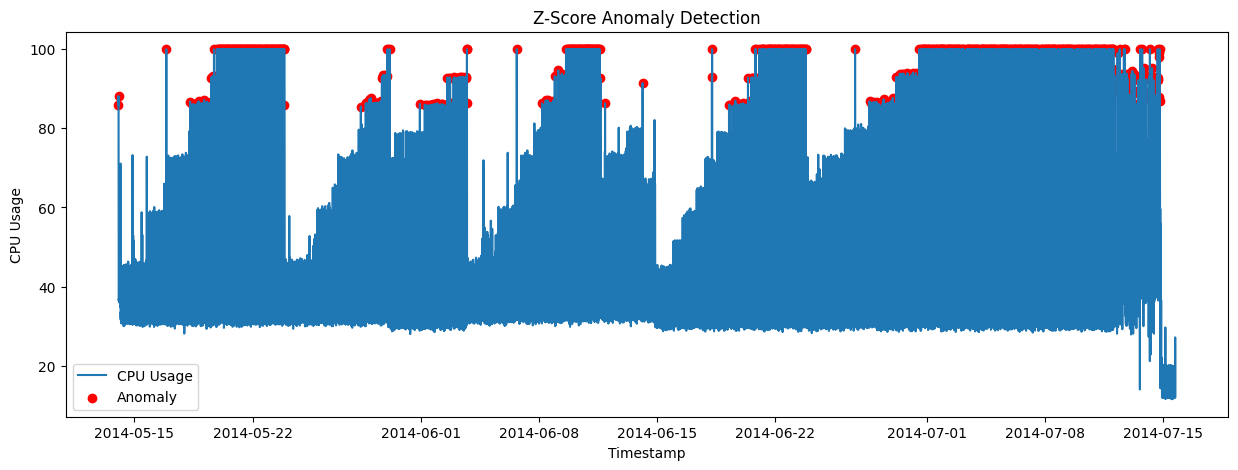

In [28]:
plt.figure(figsize=(15,5))

plt.plot(result.index, result["value"], label="CPU Usage")

plt.scatter(
    result.index[result["anomaly"]],
    result["value"][result["anomaly"]],
    color="red",
    label="Anomaly"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Timestamp")
plt.ylabel("CPU Usage")

plt.legend()
plt.show()

#  Isolation Forest Anomaly Detection

##  Overview

In this section, anomaly detection is performed using the **Isolation Forest** algorithm, an unsupervised machine learning technique specifically designed for identifying abnormal patterns in data.

Unlike statistical approaches such as Z-score detection, Isolation Forest does not rely solely on mean and standard deviation. Instead, it learns the structure of the data and isolates unusual observations automatically.

This method is highly effective for detecting anomalies in large-scale monitoring systems, cloud infrastructure, and real-time operational metrics.


In [37]:
from app.ml.isolation_forest import detect_anomalies_isolation_forest

In [38]:
data = pd.read_csv(
    "../dataset/raw/cpu_utilization_asg_misconfiguration.csv"
)

In [39]:
data = preprocess(data, scale=True)

In [40]:
result_if = detect_anomalies_isolation_forest(data)

In [41]:
result_if[result_if["anomaly"] == True].head()

,value,anomaly_score,anomaly
timestamp,,,
2014-07-13 14:54:00,-1.552723,-1,True
2014-07-14 20:04:00,-1.524013,-1,True
2014-07-14 20:09:00,-1.499012,-1,True
2014-07-14 20:14:00,-1.507069,-1,True
2014-07-14 20:19:00,-1.534372,-1,True


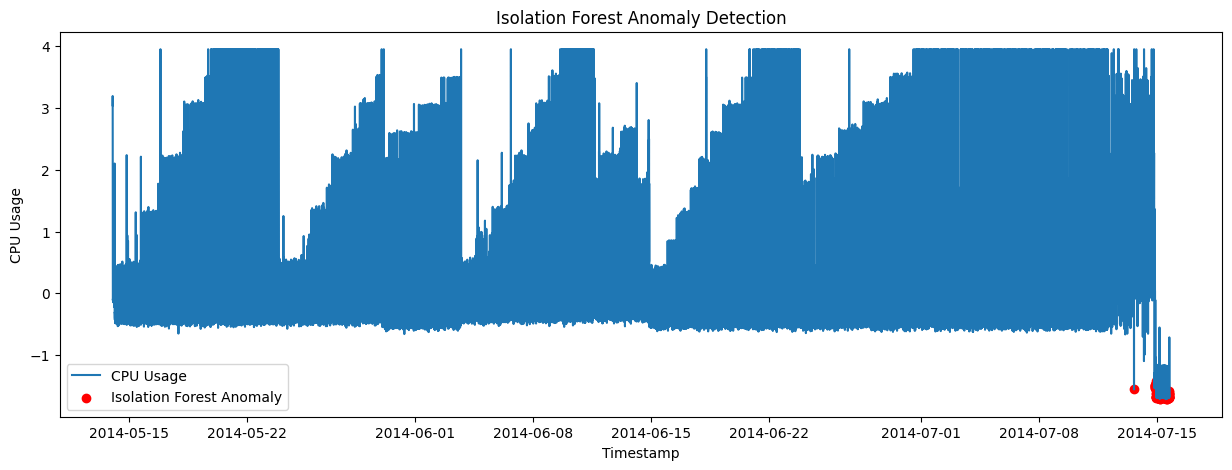

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    result_if.index,
    result_if["value"],
    label="CPU Usage"
)

plt.scatter(
    result_if.index[result_if["anomaly"]],
    result_if["value"][result_if["anomaly"]],
    color="red",
    label="Isolation Forest Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Timestamp")
plt.ylabel("CPU Usage")

plt.legend()
plt.show()

In [43]:
from app.ml.pyod_model import detect_anomalies_pyod

In [44]:
data = pd.read_csv(
    "../dataset/raw/cpu_utilization_asg_misconfiguration.csv"
)

In [45]:
data = preprocess(data, scale=True)

In [46]:
result_pyod = detect_anomalies_pyod(data)

In [47]:
result_pyod[result_pyod["anomaly"] == True].head()

,value,anomaly,anomaly_score
timestamp,,,
2014-05-14 02:04:00,0.731601,1,0.016612
2014-05-14 02:59:00,0.128629,1,0.013556
2014-05-14 03:04:00,0.731665,1,0.016676
2014-05-14 03:44:00,0.130355,1,0.011829
2014-05-18 15:09:00,2.563089,1,0.012852


C:\Users\10\AppData\Local\Temp\ipykernel_10904\2485551139.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result_pyod["value"][result_pyod["anomaly"]],


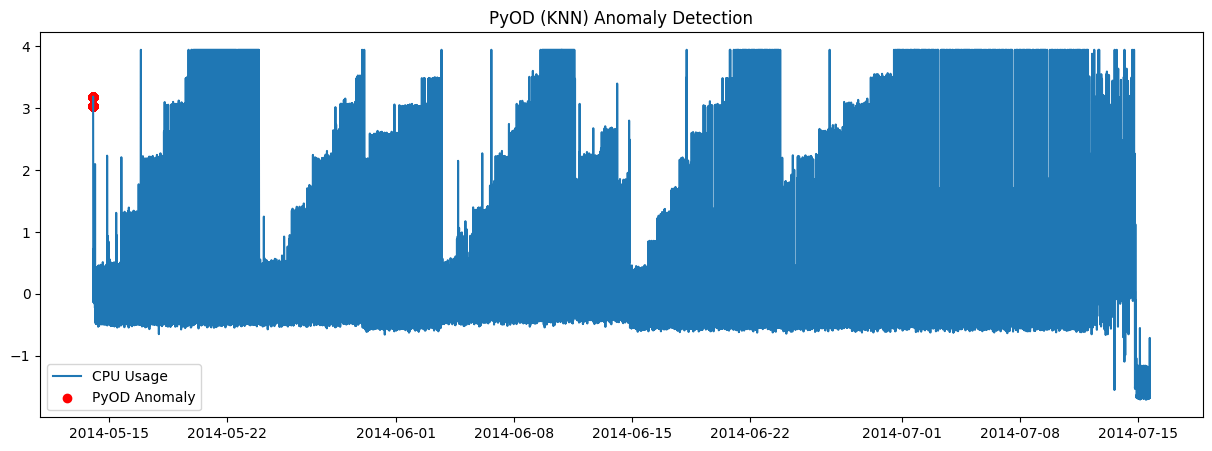

In [49]:
plt.figure(figsize=(15,5))

plt.plot(result_pyod.index, result_pyod["value"], label="CPU Usage")

plt.scatter(
    result_pyod.index[result_pyod["anomaly"]],
    result_pyod["value"][result_pyod["anomaly"]],
    color="red",
    label="PyOD Anomaly"
)

plt.title("PyOD (KNN) Anomaly Detection")
plt.legend()
plt.show()